# Partie I — MLP et ingénierie PyTorch
## Classification supervisée sur données tabulaires réelles — *Wine Quality (vin rouge)*

**Projet de fin de module — Deep Learning — EMSI 2025–2026**

---

Ce notebook est **entièrement auto-contenu** : configuration, téléchargement des données,
préparation, implémentation, expériences, évaluation et analyse critique y figurent.
Aucun chemin n'est codé en dur : tous les choix passent par l'objet `CONFIG` défini plus bas.

### Plan (aligné sur le cahier des charges)
1. **Étude théorique** : `nn.Module`, paramètres, gradient, `state_dict`, *device*, propagation avant / rétropropagation.
2. **Préparation des données** : nettoyage, encodage de la cible, normalisation, séparation *train / val / test*.
3. **Implémentation** : deux versions du MLP (`nn.Sequential` et classe personnalisée).
4. **Gestion des paramètres** : `named_parameters()`, `state_dict()`.
5. **Initialisation** : gaussienne, constante, Xavier (comparaison expérimentale).
6. **Sauvegarde / rechargement** du meilleur modèle.
7. **Device** (CPU/GPU) et cohérence données ↔ modèle.
8. **Évaluation** : accuracy, precision, recall, F1, matrice de confusion.
9. **Analyse critique** et **question de synthèse**.


## 1. Étude théorique structurée

### 1.1 `nn.Module`, l'abstraction centrale
En PyTorch, tout réseau hérite de `nn.Module`. Un module encapsule (i) des **paramètres apprenables**
(enregistrés automatiquement), (ii) d'éventuels **sous-modules**, et (iii) une méthode `forward(x)`
qui décrit la transformation entrée → sortie. L'enregistrement automatique des paramètres est ce qui
permet à l'optimiseur de les retrouver via `model.parameters()` et au moteur d'autograd de calculer
leurs gradients.

### 1.2 Paramètres et gradient
Un **paramètre** est un `torch.nn.Parameter` (un tenseur avec `requires_grad=True`). Pour une couche
linéaire $y = xW^\top + b$, les paramètres sont $W$ (poids) et $b$ (biais).
Le **gradient** $\partial \mathcal{L} / \partial \theta$ mesure la sensibilité de la perte à chaque
paramètre ; il est calculé par `loss.backward()` (rétropropagation) puis utilisé par l'optimiseur
(`optimizer.step()`) pour mettre à jour $\theta \leftarrow \theta - \eta\,\nabla_\theta \mathcal{L}$.

### 1.3 Propagation avant et rétropropagation
- **Forward** : on applique successivement couches linéaires et activations,
  $H = \mathrm{ReLU}(XW_1 + b_1)$ puis $\hat Y = HW_2 + b_2$. Autograd construit en même temps
  le graphe de calcul.
- **Backward** : par la règle de la chaîne, autograd remonte le graphe et remplit `param.grad`.

### 1.4 `state_dict`
Le `state_dict()` est un dictionnaire `{nom_de_paramètre : tenseur}`. C'est le **format standard de
sauvegarde** : on sauvegarde les *poids* (`torch.save(model.state_dict(), ...)`), pas l'objet Python,
ce qui impose de recréer l'architecture avant `load_state_dict`.

### 1.5 *Device*
Un *device* (`cpu` ou `cuda`) indique où vivent tenseurs et modèle. **Règle absolue** : les données et
le modèle impliqués dans une même opération doivent être sur le **même device**.


In [1]:
# === Imports ===
import os, time, json, random, urllib.request
from dataclasses import dataclass, field
from typing import List

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)

print("PyTorch :", torch.__version__)


PyTorch : 2.11.0+cpu


In [2]:
# === Configuration centralisée (aucune valeur codée en dur ailleurs) ===
@dataclass
class Config:
    seed: int = 42
    # Données : mirror public UCI (équivalent au dataset Kaggle "red-wine-quality").
    data_url: str = ("https://archive.ics.uci.edu/ml/machine-learning-databases/"
                     "wine-quality/winequality-red.csv")
    data_dir: str = "data"
    csv_name: str = "winequality-red.csv"
    # Cible : qualité ordinale 0-10 -> binarisation "bon vin" (qualité >= seuil).
    quality_threshold: int = 6
    # Découpage train / val / test (val et test pris sur le total).
    test_size: float = 0.15
    val_size: float = 0.15
    # Architecture MLP (modifiable -> non hard-codé).
    hidden_dims: tuple = (64, 32)
    dropout: float = 0.2
    # Optimisation.
    batch_size: int = 64
    lr: float = 1e-3
    weight_decay: float = 1e-4
    epochs: int = 80
    # Stratégies d'initialisation à comparer.
    init_strategies: tuple = ("normal", "constant", "xavier")
    # Sauvegarde.
    model_dir: str = "models"
    best_model_name: str = "mlp_wine_best.pt"

CONFIG = Config()
os.makedirs(CONFIG.data_dir, exist_ok=True)
os.makedirs(CONFIG.model_dir, exist_ok=True)

def set_seed(seed: int):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)

set_seed(CONFIG.seed)

# --- Sélection du device (fonctions utilitaires de la fiche de synthèse) ---
def try_gpu(i: int = 0):
    if torch.cuda.is_available() and torch.cuda.device_count() >= i + 1:
        return torch.device(f"cuda:{i}")
    return torch.device("cpu")

DEVICE = try_gpu()
print("Device utilisé :", DEVICE)


Device utilisé : cpu


## 2. Import et préparation des données

Le dataset **Wine Quality (vin rouge)** comporte 11 variables physico-chimiques (acidité, sucre,
alcool, sulfites...) et une note de qualité sensorielle entière de 3 à 8. Nous téléchargeons le CSV
depuis le mirror UCI (équivalent au dataset Kaggle indiqué) et le mettons en cache local.


In [3]:
def download_dataset(cfg: Config) -> str:
    """Télécharge le CSV s'il n'est pas déjà en cache local. Retourne le chemin."""
    path = os.path.join(cfg.data_dir, cfg.csv_name)
    if not os.path.exists(path):
        print("Téléchargement depuis", cfg.data_url)
        urllib.request.urlretrieve(cfg.data_url, path)
    else:
        print("Fichier déjà présent :", path)
    return path

csv_path = download_dataset(CONFIG)
# Le CSV UCI est séparé par des points-virgules.
df = pd.read_csv(csv_path, sep=";")
print("Dimensions :", df.shape)
df.head()


Téléchargement depuis https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv


Dimensions : (1599, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [4]:
# --- Inspection : valeurs manquantes, doublons, distribution de la cible ---
print("Valeurs manquantes par colonne :\n", df.isna().sum().to_string())
print("\nLignes dupliquées :", df.duplicated().sum())
print("\nDistribution de la qualité (note brute) :")
print(df["quality"].value_counts().sort_index().to_string())


Valeurs manquantes par colonne :
 fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0

Lignes dupliquées : 240

Distribution de la qualité (note brute) :
quality
3     10
4     53
5    681
6    638
7    199
8     18


Après suppression des doublons : (1359, 12)


C:\Users\the-r\AppData\Local\Temp\ipykernel_9700\637441192.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(["Ordinaire (<{})".format(CONFIG.quality_threshold),


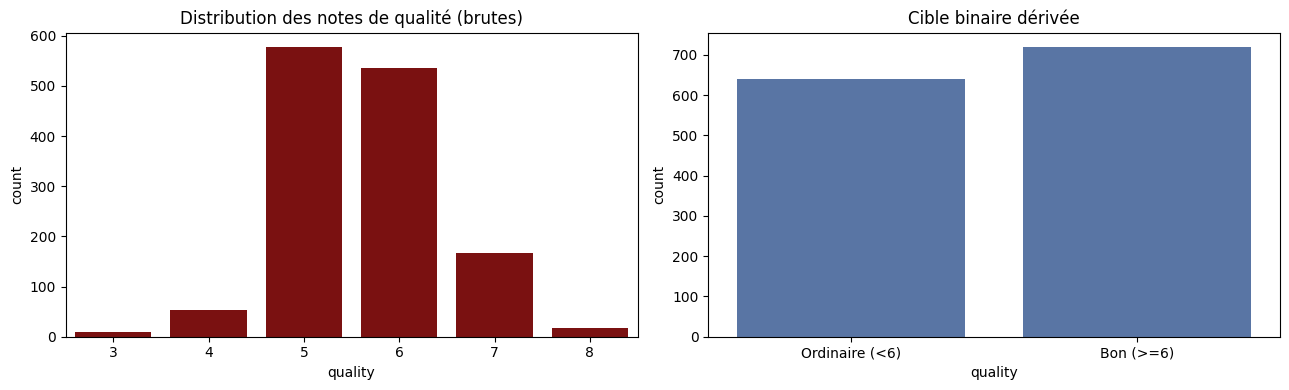

Proportion de 'bons' vins : 0.529


In [5]:
# --- Nettoyage + EDA visuelle ---
df = df.drop_duplicates().reset_index(drop=True)
print("Après suppression des doublons :", df.shape)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.countplot(x="quality", data=df, ax=axes[0], color="#8B0000")
axes[0].set_title("Distribution des notes de qualité (brutes)")
# La cible binaire : bon (>= seuil) vs ordinaire.
y_bin = (df["quality"] >= CONFIG.quality_threshold).astype(int)
sns.countplot(x=y_bin, ax=axes[1], color="#4C72B0")
axes[1].set_xticklabels(["Ordinaire (<{})".format(CONFIG.quality_threshold),
                         "Bon (>={})".format(CONFIG.quality_threshold)])
axes[1].set_title("Cible binaire dérivée")
plt.tight_layout(); plt.show()
print("Proportion de 'bons' vins :", round(y_bin.mean(), 3))


### 2.1 Choix méthodologiques
- **Encodage de la cible** : la qualité est ordinale (3–8) mais très déséquilibrée aux extrêmes
  (peu d'exemples en 3, 4, 8). Une classification multi-classes sur 6 niveaux serait dominée par le
  bruit d'annotation. Nous adoptons une **classification binaire** *bon vin* (qualité ≥ 6) vs
  *ordinaire*, qui est la formulation standard pour ce jeu de données et reste bien équilibrée.
- **Normalisation** : les variables ont des échelles très différentes. On applique un
  `StandardScaler` **ajusté uniquement sur l'ensemble d'apprentissage** (pas de fuite d'information).
- **Découpage stratifié** train / val / test pour préserver les proportions de classes.


In [6]:
# --- Construction X, y ---
feature_cols = [c for c in df.columns if c != "quality"]
X = df[feature_cols].values.astype(np.float32)
y = (df["quality"].values >= CONFIG.quality_threshold).astype(np.int64)

# Découpage stratifié train / (val+test) puis val / test.
X_train, X_tmp, y_train, y_tmp = train_test_split(
    X, y, test_size=CONFIG.test_size + CONFIG.val_size,
    stratify=y, random_state=CONFIG.seed)
rel_test = CONFIG.test_size / (CONFIG.test_size + CONFIG.val_size)
X_val, X_test, y_val, y_test = train_test_split(
    X_tmp, y_tmp, test_size=rel_test, stratify=y_tmp, random_state=CONFIG.seed)

# Normalisation : fit sur train uniquement.
scaler = StandardScaler().fit(X_train)
X_train = scaler.transform(X_train).astype(np.float32)
X_val   = scaler.transform(X_val).astype(np.float32)
X_test  = scaler.transform(X_test).astype(np.float32)

print(f"Train {X_train.shape} | Val {X_val.shape} | Test {X_test.shape}")
print("Nb features :", len(feature_cols))

# --- DataLoaders ---
def make_loader(X, y, batch_size, shuffle):
    ds = TensorDataset(torch.from_numpy(X), torch.from_numpy(y))
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)

train_loader = make_loader(X_train, y_train, CONFIG.batch_size, True)
val_loader   = make_loader(X_val,   y_val,   CONFIG.batch_size, False)
test_loader  = make_loader(X_test,  y_test,  CONFIG.batch_size, False)
N_FEATURES, N_CLASSES = X_train.shape[1], int(len(np.unique(y)))


Train (951, 11) | Val (204, 11) | Test (204, 11)
Nb features : 11


## 3. Implémentation du MLP — deux versions

Le cahier des charges demande **deux constructions équivalentes** : l'une via `nn.Sequential`
(rapide, déclarative), l'autre via une **classe personnalisée** héritant de `nn.Module` (plus
flexible : branchements, opérations spécifiques dans `forward`). Les deux partagent la même
configuration d'architecture (`hidden_dims`), ce qui évite toute duplication codée en dur.


In [7]:
def build_mlp_sequential(in_dim, hidden_dims, out_dim, dropout):
    """Version nn.Sequential : enchaînement déclaratif Linear -> ReLU -> Dropout."""
    layers, prev = [], in_dim
    for h in hidden_dims:
        layers += [nn.Linear(prev, h), nn.ReLU(), nn.Dropout(dropout)]
        prev = h
    layers += [nn.Linear(prev, out_dim)]
    return nn.Sequential(*layers)


class MLPCustom(nn.Module):
    """Version classe personnalisée : même architecture, contrôle explicite du forward."""
    def __init__(self, in_dim, hidden_dims, out_dim, dropout):
        super().__init__()           # indispensable pour enregistrer les paramètres
        self.blocks = nn.ModuleList()
        prev = in_dim
        for h in hidden_dims:
            self.blocks.append(nn.Linear(prev, h))
            prev = h
        self.dropout = nn.Dropout(dropout)
        self.head = nn.Linear(prev, out_dim)

    def forward(self, x):
        for lin in self.blocks:
            x = self.dropout(torch.relu(lin(x)))
        return self.head(x)


# Instanciation des deux versions.
mlp_seq = build_mlp_sequential(N_FEATURES, CONFIG.hidden_dims, N_CLASSES, CONFIG.dropout)
mlp_cls = MLPCustom(N_FEATURES, CONFIG.hidden_dims, N_CLASSES, CONFIG.dropout)
print(mlp_seq)
print(mlp_cls)


Sequential(
  (0): Linear(in_features=11, out_features=64, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.2, inplace=False)
  (3): Linear(in_features=64, out_features=32, bias=True)
  (4): ReLU()
  (5): Dropout(p=0.2, inplace=False)
  (6): Linear(in_features=32, out_features=2, bias=True)
)
MLPCustom(
  (blocks): ModuleList(
    (0): Linear(in_features=11, out_features=64, bias=True)
    (1): Linear(in_features=64, out_features=32, bias=True)
  )
  (dropout): Dropout(p=0.2, inplace=False)
  (head): Linear(in_features=32, out_features=2, bias=True)
)


## 4. Gestion et inspection des paramètres

On utilise `named_parameters()` (structure, dimensions, comptage) et `state_dict()` (format de
sauvegarde). On vérifie aussi que **les deux versions ont le même nombre de paramètres**, confirmant
leur équivalence architecturale.


In [8]:
def describe_parameters(model, name):
    total = 0
    print(f"=== {name} ===")
    for pname, p in model.named_parameters():
        print(f"  {pname:<20} shape={tuple(p.shape)}  n={p.numel()}")
        total += p.numel()
    print(f"  -> total paramètres : {total}\n")
    return total

t_seq = describe_parameters(mlp_seq, "MLP nn.Sequential")
t_cls = describe_parameters(mlp_cls, "MLP classe personnalisée")
assert t_seq == t_cls, "Les deux versions devraient avoir le même nombre de paramètres."

# state_dict : clés = noms des paramètres.
print("Clés du state_dict (Sequential) :", list(mlp_seq.state_dict().keys()))

# Avant backward, le gradient est None ; il apparaît après loss.backward().
xb, yb = next(iter(train_loader))
out = mlp_seq(xb)
print("\nGradient avant backward :", mlp_seq[0].weight.grad)
loss_demo = nn.functional.cross_entropy(out, yb)
loss_demo.backward()
print("Norme du gradient de la 1re couche après backward :",
      round(mlp_seq[0].weight.grad.norm().item(), 4))
mlp_seq.zero_grad()


=== MLP nn.Sequential ===
  0.weight             shape=(64, 11)  n=704
  0.bias               shape=(64,)  n=64
  3.weight             shape=(32, 64)  n=2048
  3.bias               shape=(32,)  n=32
  6.weight             shape=(2, 32)  n=64
  6.bias               shape=(2,)  n=2
  -> total paramètres : 2914

=== MLP classe personnalisée ===
  blocks.0.weight      shape=(64, 11)  n=704
  blocks.0.bias        shape=(64,)  n=64
  blocks.1.weight      shape=(32, 64)  n=2048
  blocks.1.bias        shape=(32,)  n=32
  head.weight          shape=(2, 32)  n=64
  head.bias            shape=(2,)  n=2
  -> total paramètres : 2914

Clés du state_dict (Sequential) : ['0.weight', '0.bias', '3.weight', '3.bias', '6.weight', '6.bias']

Gradient avant backward : None
Norme du gradient de la 1re couche après backward : 0.0601


## 5. Stratégies d'initialisation

Nous comparons **trois stratégies** (cahier des charges) :
- **Gaussienne** : $W \sim \mathcal{N}(0, 0.01^2)$ — petits poids, évite la saturation initiale.
- **Constante** : $W = 1$ — pédagogiquement utile mais **brise la symétrie** : tous les neurones d'une
  couche apprennent la même chose → modèle inefficace (à démontrer expérimentalement).
- **Xavier** : variance calibrée pour stabiliser la propagation du signal — souvent le meilleur choix.

Chaque modèle est entraîné dans les **mêmes conditions** ; seule l'initialisation change.


In [9]:
def init_normal(m):
    if isinstance(m, nn.Linear):
        nn.init.normal_(m.weight, mean=0.0, std=0.01); nn.init.zeros_(m.bias)

def init_constant(m):
    if isinstance(m, nn.Linear):
        nn.init.constant_(m.weight, 1.0); nn.init.zeros_(m.bias)

def init_xavier(m):
    if isinstance(m, nn.Linear):
        nn.init.xavier_uniform_(m.weight); nn.init.zeros_(m.bias)

INIT_FUNCS = {"normal": init_normal, "constant": init_constant, "xavier": init_xavier}


In [10]:
@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    ys, ps, losses = [], [], []
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        logits = model(xb)
        losses.append(nn.functional.cross_entropy(logits, yb, reduction="sum").item())
        ps.append(logits.argmax(1).cpu()); ys.append(yb.cpu())
    y_true = torch.cat(ys).numpy(); y_pred = torch.cat(ps).numpy()
    n = len(y_true)
    return {"loss": sum(losses)/n,
            "acc": accuracy_score(y_true, y_pred)}, y_true, y_pred


def train_model(model, train_loader, val_loader, cfg, device, verbose=False):
    model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
    crit = nn.CrossEntropyLoss()
    hist = {"train_loss": [], "val_loss": [], "val_acc": []}
    best_acc, best_state = -1.0, None
    for ep in range(cfg.epochs):
        model.train(); run = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            loss = crit(model(xb), yb)
            loss.backward()
            opt.step()
            run += loss.item() * xb.size(0)
        train_loss = run / len(train_loader.dataset)
        val_metrics, _, _ = evaluate(model, val_loader, device)
        hist["train_loss"].append(train_loss)
        hist["val_loss"].append(val_metrics["loss"])
        hist["val_acc"].append(val_metrics["acc"])
        if val_metrics["acc"] > best_acc:
            best_acc = val_metrics["acc"]
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        if verbose and (ep+1) % 20 == 0:
            print(f"  epoch {ep+1:3d} | train {train_loss:.4f} | "
                  f"val {val_metrics['loss']:.4f} | val_acc {val_metrics['acc']:.4f}")
    return hist, best_acc, best_state


In [11]:
# --- Comparaison des initialisations (architecture personnalisée, mêmes hyperparamètres) ---
set_seed(CONFIG.seed)
init_results = {}
for strat in CONFIG.init_strategies:
    set_seed(CONFIG.seed)  # même point de départ pour le DataLoader/shuffle
    model = MLPCustom(N_FEATURES, CONFIG.hidden_dims, N_CLASSES, CONFIG.dropout)
    model.apply(INIT_FUNCS[strat])
    print(f"\n>>> Initialisation : {strat}")
    hist, best_acc, _ = train_model(model, train_loader, val_loader, CONFIG, DEVICE, verbose=True)
    init_results[strat] = {"hist": hist, "best_val_acc": best_acc}
    print(f"    meilleure val_acc = {best_acc:.4f}")



>>> Initialisation : normal


  epoch  20 | train 0.4957 | val 0.4969 | val_acc 0.7304


  epoch  40 | train 0.4827 | val 0.4892 | val_acc 0.7598


  epoch  60 | train 0.4837 | val 0.4941 | val_acc 0.7598


  epoch  80 | train 0.4566 | val 0.4864 | val_acc 0.7696
    meilleure val_acc = 0.7745

>>> Initialisation : constant


...

  epoch  80 | train 0.7221 | val 0.6921 | val_acc 0.5294
    meilleure val_acc = 0.5490

>>> Initialisation : xavier


  epoch  20 | train 0.4860 | val 0.4724 | val_acc 0.7549


  epoch  40 | train 0.4596 | val 0.4668 | val_acc 0.7941


  epoch  60 | train 0.4662 | val 0.4727 | val_acc 0.7794


  epoch  80 | train 0.4419 | val 0.4706 | val_acc 0.7843
    meilleure val_acc = 0.7941


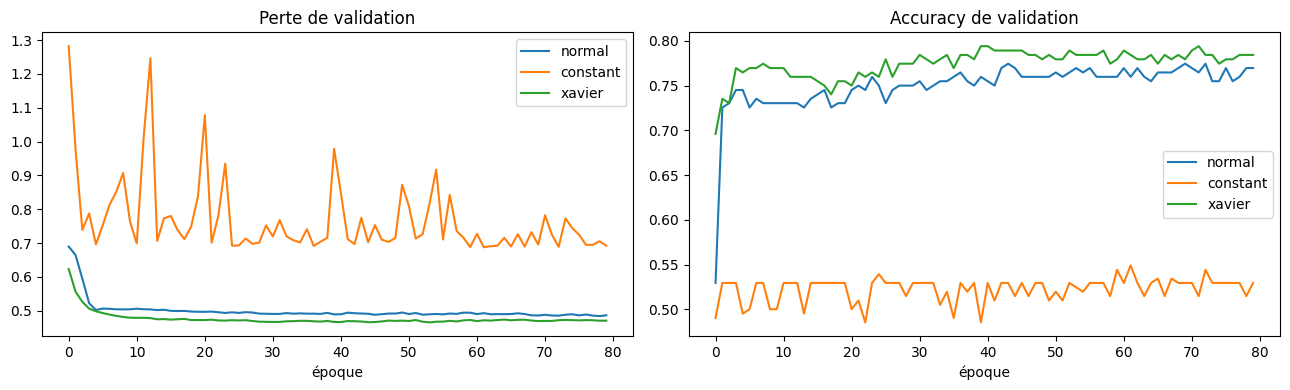

          best_val_acc
normal          0.7745
constant        0.5490
xavier          0.7941


In [12]:
# --- Courbes de convergence selon l'initialisation ---
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for strat, r in init_results.items():
    axes[0].plot(r["hist"]["val_loss"], label=strat)
    axes[1].plot(r["hist"]["val_acc"], label=strat)
axes[0].set_title("Perte de validation"); axes[0].set_xlabel("époque"); axes[0].legend()
axes[1].set_title("Accuracy de validation"); axes[1].set_xlabel("époque"); axes[1].legend()
plt.tight_layout(); plt.show()

summary_init = pd.DataFrame({s: {"best_val_acc": round(r["best_val_acc"], 4)}
                             for s, r in init_results.items()}).T
print(summary_init)


**Interprétation attendue.** L'initialisation **constante** stagne : tous les neurones d'une
couche étant identiques, ils reçoivent le même gradient et restent identiques (problème de symétrie),
ce qui plafonne l'accuracy autour de la classe majoritaire. Les initialisations **gaussienne** et
**Xavier** brisent la symétrie ; Xavier converge en général plus vite et plus haut car elle maintient
une variance du signal stable à travers les couches.


## 6. Entraînement du modèle retenu, sauvegarde et rechargement

On sélectionne la **meilleure stratégie d'initialisation** (sur la validation), on réentraîne le
modèle final, on **sauvegarde son `state_dict`** puis on le **recharge** dans une architecture neuve
pour vérifier l'égalité des prédictions (bonne pratique de la fiche de synthèse).


In [13]:
# Meilleure init d'après la validation.
best_init = max(init_results, key=lambda s: init_results[s]["best_val_acc"])
print("Initialisation retenue :", best_init)

set_seed(CONFIG.seed)
final_model = MLPCustom(N_FEATURES, CONFIG.hidden_dims, N_CLASSES, CONFIG.dropout)
final_model.apply(INIT_FUNCS[best_init])
hist, best_acc, best_state = train_model(final_model, train_loader, val_loader,
                                         CONFIG, DEVICE, verbose=True)

# Sauvegarde du MEILLEUR état (pas le dernier) sous forme de state_dict.
best_path = os.path.join(CONFIG.model_dir, CONFIG.best_model_name)
torch.save(best_state, best_path)
print("Modèle sauvegardé :", best_path)

# Rechargement dans une architecture recréée à l'identique.
reloaded = MLPCustom(N_FEATURES, CONFIG.hidden_dims, N_CLASSES, CONFIG.dropout).to(DEVICE)
reloaded.load_state_dict(torch.load(best_path, map_location=DEVICE))
reloaded.eval()

# Vérification : mêmes prédictions sur le test => rechargement correct.
final_model.load_state_dict(best_state)
m1, yt1, yp1 = evaluate(final_model.to(DEVICE), test_loader, DEVICE)
m2, yt2, yp2 = evaluate(reloaded, test_loader, DEVICE)
print(f"Accuracy test (modèle entraîné) : {m1['acc']:.4f}")
print(f"Accuracy test (modèle rechargé) : {m2['acc']:.4f}")
print("Prédictions identiques après rechargement :", bool(np.array_equal(yp1, yp2)))


Initialisation retenue : xavier


  epoch  20 | train 0.4860 | val 0.4724 | val_acc 0.7549


  epoch  40 | train 0.4596 | val 0.4668 | val_acc 0.7941


  epoch  60 | train 0.4662 | val 0.4727 | val_acc 0.7794


  epoch  80 | train 0.4419 | val 0.4706 | val_acc 0.7843
Modèle sauvegardé : models\mlp_wine_best.pt
Accuracy test (modèle entraîné) : 0.7255
Accuracy test (modèle rechargé) : 0.7255
Prédictions identiques après rechargement : True


## 7. Cohérence device ↔ données

On vérifie explicitement que le modèle et les tenseurs d'entrée résident sur le **même device** —
condition nécessaire pour que le calcul s'exécute sans erreur.


In [14]:
xb, yb = next(iter(test_loader))
xb = xb.to(DEVICE)
out = reloaded(xb)
print("Device du modèle :", next(reloaded.parameters()).device)
print("Device des données :", xb.device)
print("Device de la sortie :", out.device)
assert next(reloaded.parameters()).device == xb.device
print("=> Cohérence vérifiée.")


Device du modèle : cpu
Device des données : cpu
Device de la sortie : cpu
=> Cohérence vérifiée.


## 8. Évaluation finale — métriques adaptées

Conformément au cahier des charges : **accuracy, precision, recall, F1-score** et **matrice de
confusion**, sur l'ensemble de **test** (jamais vu pendant l'entraînement ni la sélection de modèle).


Métriques (test) :
  accuracy  : 0.7255
  precision : 0.7889
  recall    : 0.6574
  f1        : 0.7172

Rapport de classification :
               precision    recall  f1-score   support

   Ordinaire       0.68      0.80      0.73        96
         Bon       0.79      0.66      0.72       108

    accuracy                           0.73       204
   macro avg       0.73      0.73      0.73       204
weighted avg       0.74      0.73      0.72       204



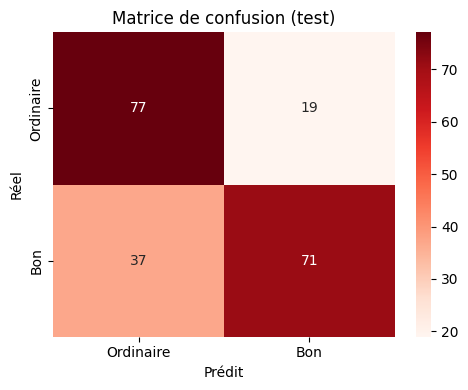

In [15]:
_, y_true, y_pred = evaluate(reloaded, test_loader, DEVICE)
metrics = {
    "accuracy":  accuracy_score(y_true, y_pred),
    "precision": precision_score(y_true, y_pred),
    "recall":    recall_score(y_true, y_pred),
    "f1":        f1_score(y_true, y_pred),
}
print("Métriques (test) :")
for k, v in metrics.items():
    print(f"  {k:<10}: {v:.4f}")

print("\nRapport de classification :\n",
      classification_report(y_true, y_pred,
                            target_names=["Ordinaire", "Bon"]))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Reds",
            xticklabels=["Ordinaire", "Bon"], yticklabels=["Ordinaire", "Bon"])
plt.xlabel("Prédit"); plt.ylabel("Réel"); plt.title("Matrice de confusion (test)")
plt.tight_layout(); plt.show()


## 9. Analyse critique

**Lecture des résultats.**
- Le MLP atteint une accuracy de test cohérente avec la littérature sur ce jeu (typiquement
  0,72–0,78 en binaire). La matrice de confusion montre où se situent les erreurs : la frontière
  qualité = 6 est **intrinsèquement bruitée** (deux vins quasi identiques peuvent recevoir 5 ou 6
  selon le dégustateur), ce qui borne mécaniquement la performance atteignable.
- L'expérience sur les initialisations confirme la théorie : l'initialisation **constante** est
  inutilisable (symétrie non brisée), tandis que **Xavier** offre la convergence la plus stable.

**Limites du MLP sur données tabulaires.**
1. Le MLP traite chaque variable indépendamment via des combinaisons linéaires : il ne tire pas parti
   d'une structure spatiale/temporelle (il n'y en a pas ici), mais doit *apprendre* toutes les
   interactions, ce que des modèles à base d'arbres (Random Forest, Gradient Boosting) capturent
   souvent mieux et plus simplement sur ce type de données.
2. Le **bruit d'annotation** et le **déséquilibre résiduel** limitent le rappel sur la classe « Bon ».
3. La **petite taille** du jeu (~1,4k lignes après déduplication) favorise le surapprentissage ;
   d'où le dropout et la régularisation `weight_decay`.

**Pistes d'amélioration.** validation croisée k-fold, recherche d'hyperparamètres, pondération des
classes, ou comparaison à un Gradient Boosting comme référence.


## Question de synthèse — Partie I

> *Dans quelle mesure un MLP bien paramétré constitue-t-il une solution pertinente pour la
> classification tabulaire sur un dataset réel, et quelles sont ses principales limites au regard de
> la structure statistique des données étudiées ?*

**Réponse argumentée.**
Un MLP bien paramétré (normalisation des entrées, initialisation Xavier, régularisation, sélection
sur validation) est un **approximateur universel** capable de modéliser des interactions non linéaires
entre variables physico-chimiques. Sur *Wine Quality*, il atteint une performance honorable et **stable**,
ce qui valide théorie et méthodologie : la propagation avant calcule une représentation cachée
$H=\mathrm{ReLU}(XW_1+b_1)$, la rétropropagation ajuste $\theta$, et le bon contrôle de
l'initialisation/du device garantit un entraînement reproductible.

Ses **limites** tiennent à la **structure statistique des données** : (i) les données tabulaires
n'ont **ni localité ni invariance** à exploiter — l'inductive bias d'un MLP (couches denses) n'apporte
donc pas d'avantage décisif face aux modèles à arbres souvent supérieurs ici ; (ii) la cible est
**ordinale et bruitée**, plafonnant la séparabilité ; (iii) le **faible volume** de données accentue
le risque de surapprentissage. En somme, le MLP est *pertinent et pédagogiquement central*, mais
**pas nécessairement optimal** pour ce régime tabulaire — ce qui motive, dans les parties suivantes,
des architectures dont l'inductive bias **correspond** à la structure des données (CNN pour la
localité spatiale, RNN pour la dépendance temporelle).
